# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Цели и задачи проекта


Проверка гипотезы: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложнии, чем пользователи из Москвы. 
- Нулевая гипотеза 
H0: μ СПб ≤ μ Москва
Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.
- Альтернативная гипотеза 
H1: μ СПб > μ Москва
Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

## Описание данных


Данные представлены за период с 1 сентября по 11 декабря 2024 года. 

- Таблица bookmate.audition содержит данные об активности пользователей и состоит из следующих полей:
  - audition_id — уникальный идентификатор сессии чтения или прослушивания;
  - puid — идентификатор пользователя;
  - usage_platform_ru — название платформы, с помощью которой пользователь слушал контент;
  -  msk_business_dt_str — дата события в формате строки (московское время);
  - app_version — версия приложения, которая использовалась для чтения или прослушивания;
  - adult_content_flg — был ли это контент для взрослых: True или False;
  - hours — длительность чтения или прослушивания в часах;
  - hours_sessions_long — продолжительность длинных сессий чтения или прослушивания в часах;
  - kids_content_flg — был ли это детский контент: True или False;
  - main_content_id — идентификатор основного контента;
  - usage_geo_id — идентификатор географического местоположения.
- Таблица bookmate.content содержит данные о контенте и состоит из следующих полей:
  - main_content_id — идентификатор основного контента;
  - main_author_id — идентификатор основного автора контента;
  - main_content_type — тип контента;
  - main_content_name— название контента;
  - main_content_duration_hours — длительность контента в часах;
  - published_topic_title_list — список жанров контента.
- Таблица bookmate.author содержит данные об авторах контента и состоит из следующих полей:
  - main_author_id — идентификатор основного автора контента;
  - main_author_name — имя основного автора контента.
- Таблица bookmate.geo содержит данные о местоположении и состоит из следующих полей:
  - usage_geo_id — идентификатор географического положения;
  - usage_geo_id_name — город или регион географического положения;
  - usage_country_name — страна географического положения.

## Содержимое проекта


1. Проверка гипотезы в Python 
2. Составление аналитической записки
---

## 1. Загрузка данных и знакомство с ними


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [31]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. 

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [32]:
#Проверка на дубликаты
#Уникальные пользователи
num_unique_users = df['puid'].nunique()
#Кол-во записей
num_total_rows = len(df)

print(f"Всего строк: {num_total_rows}")
print(f"Уникальных пользователей: {num_unique_users}")

#Дубликаты
num_duplicates = num_total_rows - num_unique_users
print(f"Количество повторов: {num_duplicates}")

Всего строк: 8784
Уникальных пользователей: 8540
Количество повторов: 244


In [33]:
#Удаляем дубликаты
df = df.drop_duplicates(subset='puid', keep='first')

In [34]:
#Статистики
group_stats = df.groupby('city')['hours'].describe()
print(group_stats)

                  count       mean        std       min       25%       50%  \
city                                                                          
Москва           6234.0  10.881092  36.851683  0.000018  0.059903  0.924498   
Санкт-Петербург  2306.0  11.264433  39.831755  0.000025  0.060173  0.875355   

                      75%         max  
city                                   
Москва           5.939972  857.209373  
Санкт-Петербург  6.138424  978.764775  


In [35]:
#Данные по городоам
msk = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

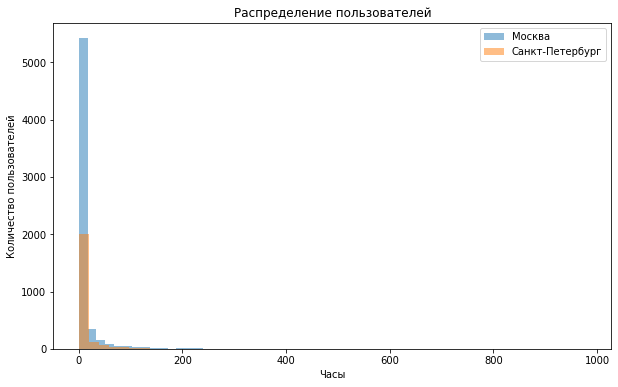

In [36]:
#Гистограмма по городам
plt.figure(figsize=(10, 6))

plt.hist(msk, bins=50, alpha=0.5, label='Москва')
plt.hist(spb, bins=50, alpha=0.5, label='Санкт-Петербург')

plt.legend()
plt.xlabel('Часы')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей')

plt.show()

In [37]:
#Проводим t-тест
t_stat, p_value = stats.ttest_ind(
    spb, 
    msk, 
    equal_var=False, 
    alternative='greater' 
)

print(f"p_value = {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Отвергаем H0: Средняя активность пользователей в Санкт-Петербурге больше")
else:
    print("Нет оснований отвергнуть H0: статистически значимых различий между городами нет")

p_value = 0.3435708118766314
Нет оснований отвергнуть H0: статистически значимых различий между городами нет


## 3. Аналитическая записка


1. Выбранный тип t-теста и уровень статистической значимости.

Для проверки гипотезы был использован односторонний t-тест для двух независимых выборок, поскольку сравниваются средние значения активности пользователей в двух группах (Москва и Санкт-Петербург), и не предполагается равенство дисперсий.
Уровень статистической значимости принят 0.05.

2. Результат теста, или p-value.

По результатам теста было получено значение p-value = 0.344.

3. Вывод на основе полученного p-value, то есть интерпретацию результатов.

Полученное значение p-value (0.343) превышает уровень значимости 0.05. Это означает, что наблюдаемое различие в средней активности пользователей может быть объяснено случайными колебаниями данных.
Следовательно, нет оснований отвергнуть нулевую гипотезу. Статистически значимых доказательств того, что пользователи из Санкт-Петербурга проводят больше времени за чтением и прослушиванием контента, чем пользователи из Москвы, не обнаружено.

4. Одну или две возможные причины, объясняющие полученные результаты.

- Действительно отсутствуют различия между пользователями в Москве и Санкт-Петербурге, они могут потреблять схожий контент. 
- Внутри каждой группы может быть большой разброс значений (например, наличие как очень активных, так и малоактивных пользователей), что снижает способность теста выявить различия между средними значениями.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Цели исследования.



Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.
Цель исследования: оценить корректность проведения теста и проанализировать его результаты.

## 2. Загружаем данные


In [38]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

## 3. По таблице `ab_test_participants` оцениваем корректность проведения теста:

 

In [39]:
#Тесты
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

In [40]:
#Участники теста
test_name = "interface_eu_test"
test_users = participants[participants['ab_test'] == test_name]['user_id'].unique()
len(test_users) 

10850

In [41]:
#Распределение по группам
test_users_df = participants[participants['ab_test'] == test_name].copy()
group_counts = test_users_df['group'].value_counts()
print(f"Количество пользователей в каждой группе: {group_counts}")
group_ratios = group_counts / group_counts.sum()
print(f"Доля пользователей по группам: {group_ratios}")

Количество пользователей в каждой группе: B    5467
A    5383
Name: group, dtype: int64
Доля пользователей по группам: B    0.503871
A    0.496129
Name: group, dtype: float64


In [42]:
#Кол-во тестов у каждого пользователя
user_test_counts = participants.groupby('user_id')['ab_test'].nunique()

#Пользователи, участвующие более чем в одном тесте
overlapping_users = user_test_counts[user_test_counts > 1]
len(overlapping_users)

887

In [43]:
overlapping_users = user_test_counts[user_test_counts > 1].index

#Исключаем из теста
test_users_clean = test_users_df[~test_users_df['user_id'].isin(overlapping_users)]
print(f"Количество участников после очистки: {len(test_users_clean)}") 

Количество участников после очистки: 9963


In [44]:
#Фильтруем participants
participants_clean = participants[
    ~participants['user_id'].isin(overlapping_users)
]

#Исключаем
test_name = "interface_eu_test"
test_users_clean = participants_clean[
    participants_clean['ab_test'] == test_name
]

In [45]:
#Проверка распределения
group_counts = test_users_clean['group'].value_counts()
group_ratios = group_counts / group_counts.sum()

print("Количество пользователей по группам:")
print(group_counts)

print("\nДоли пользователей по группам:")
print(group_ratios)

Количество пользователей по группам:
B    5011
A    4952
Name: group, dtype: int64

Доли пользователей по группам:
B    0.502961
A    0.497039
Name: group, dtype: float64


In [46]:
#События только для участников теста
test_events = events[events['user_id'].isin(test_users)].copy()
print(len(test_events), "событий")
print(test_events['user_id'].nunique(), "уникальных пользователей")

79715 событий
10850 уникальных пользователей


In [47]:
#Кол-во событий каждого типа
test_events['event_name'].value_counts()

login           29617
product_page    18982
registration    10850
purchase        10225
product_cart    10041
Name: event_name, dtype: int64

In [48]:
#Преобразуем даты в datetime
test_events['event_dt'] = pd.to_datetime(test_events['event_dt'])

#Выделяем события регистрации
registrations = test_events[test_events['event_name'] == 'registration'][['user_id', 'event_dt']]
registrations = registrations.rename(columns={'event_dt': 'reg_dt'})
registrations.head()

,user_id,reg_dt
64672,5F506CEBEDC05D30,2020-12-06 14:10:01
64946,51278A006E918D97,2020-12-06 14:37:25
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22
67873,275A8D6254ACF530,2020-12-06 19:36:54
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20


In [49]:
#добавляем дату регистрации к каждому событию пользователя
events_with_reg = test_events.merge(registrations, on='user_id', how='left')

#Рассчитываем лайфтайм события: сколько дней прошло с момента регистрации
events_with_reg['lifetime_days'] = (events_with_reg['event_dt'] - events_with_reg['reg_dt']).dt.total_seconds() / (60*60*24)
events_with_reg.head()

,user_id,event_dt,event_name,details,reg_dt,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.0


In [50]:
#Фильтруем по лайфтайму <= 7 дней
events_7days = events_with_reg[events_with_reg['lifetime_days'] <= 7].copy()

print(f"Всего событий в первые 7 дней: {len(events_7days)}")
print(f"Уникальных пользователей: {events_7days['user_id'].nunique()}")

Всего событий в первые 7 дней: 68949
Уникальных пользователей: 10850


Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [51]:
from statsmodels.stats.power import NormalIndPower
import math

p1 = 0.3         
p2 = 0.35        
alpha = 0.05     
power = 0.8     

#Среднее p
effect_size = (p2 - p1) / math.sqrt(p1*(1-p1))  
analysis = NormalIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, alternative='two-sided')

print(f"Размер выборки на одну группу: {math.ceil(sample_size)}")
print(f"Общий размер выборки (две группы): {math.ceil(2*sample_size)}")

Размер выборки на одну группу: 1319
Общий размер выборки (две группы): 2638


In [52]:
#Оставляем только события покупки
purchases = events_7days[events_7days['event_name'] == 'purchase'].copy()

#Добавляем информацию о группе пользователя
purchases = purchases.merge(
    test_users_df[['user_id', 'group']], 
    on='user_id', 
    how='left'
)

In [53]:
#Кол-во уникальных покупателей в каждой группе
buyers_per_group = purchases.groupby('group')['user_id'].nunique()

#Общее кол-во пользователей в каждой группе
total_users_per_group = test_users_df.groupby('group')['user_id'].nunique()

#Таблица
summary = pd.DataFrame({
    'total_users': total_users_per_group,
    'buyers': buyers_per_group
}).fillna(0).astype(int)

print(summary)

       total_users  buyers
group                     
A             5383    1480
B             5467    1600


In [54]:
#Конверсия покупки
summary['conversion'] = summary['buyers'] / summary['total_users']
print(summary)

       total_users  buyers  conversion
group                                 
A             5383    1480    0.274940
B             5467    1600    0.292665


In [55]:
#Конверсии по группам
conv_A = summary.loc['A', 'conversion']
conv_B = summary.loc['B', 'conversion']

#Абсолютное изменение (в процентных пунктах)
abs_change = conv_B - conv_A

#Относительное изменение (в процентах)
rel_change = (conv_B - conv_A) / conv_A * 100

print(f"Конверсия A: {conv_A:.4f}")
print(f"Конверсия B: {conv_B:.4f}")

print(f"\nАбсолютное изменение: {abs_change:.4f}")
print(f"Относительное изменение: {rel_change:.2f}%")

Конверсия A: 0.2749
Конверсия B: 0.2927

Абсолютное изменение: 0.0177
Относительное изменение: 6.45%


## 4. Проводим оценку результатов A/B-тестирования:

- Нулевая гипотеза (H₀):
  - Конверсия пользователей в группе B равна конверсии пользователей в группе A. Изменения интерфейса не влияют на вероятность покупки.
- Альтернативная гипотеза (H₁):
  -  Конверсия пользователей в группе A и группе B различаются.

In [56]:
from statsmodels.stats.proportion import proportions_ztest

In [57]:
success_A = summary.loc['A', 'buyers']
success_B = summary.loc['B', 'buyers']

nobs_A = summary.loc['A', 'total_users']
nobs_B = summary.loc['B', 'total_users']

counts = [success_A, success_B]
nobs = [nobs_A, nobs_B]

In [58]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=nobs,
    alternative='two-sided'
)

print(f"z_stat = {z_stat:.4f}")
print(f"p_value = {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print(f"p-value < alpha ({p_value:.4f} < {alpha})")
    print("Нулевая гипотеза ОТВЕРГАЕТСЯ: различия статистически значимы")
else:
    print(f"p-value >= alpha ({p_value:.4f} >= {alpha})")
    print("Нулевая гипотеза НЕ ОТВЕРГАЕТСЯ: статистически значимых различий нет")

z_stat = -2.0474
p_value = 0.0406
p-value < alpha (0.0406 < 0.05)
Нулевая гипотеза ОТВЕРГАЕТСЯ: различия статистически значимы


**Выводы:**

1. Качество эксперимента и выборки

В рамках A/B-тестирования была проведена проверка корректности выборки:

Участники теста распределены равномерно:
Группа A (контроль): 4 952 пользователя
Группа B (тест): 5 011 пользователя
Пересечения пользователей с другими тестами были исключены, что устранило искажения результатов.
Анализ проводился в рамках окна 7 дней после регистрации, что обеспечивает единые условия сравнения пользователей.

- Таким образом, можно считать, что данные пригодны для корректного A/B-анализа.

2. Результаты по метрике (конверсии)

Конверсия в покупку за первые 7 дней составила:

Группа A (контроль): 27.5%
Группа B (тест): 29.3%

- Наблюдается увеличение конверсии в тестовой группе.

Абсолютное изменение: +1.77 процентных пункта
Относительное изменение: +6.45%

3. Сравнение с целевым показателем

Целью A/B-теста было подтверждение гипотезы о том, что новый интерфейс:

увеличивает конверсию пользователей в покупку

Ожидаемый эффект — рост конверсии в тестовой группе относительно контрольной.

Фактический результат: наблюдается положительный прирост конверсии (+1.77 процентных пункта)

- Таким образом, целевой эффект достигнут — улучшение конверсии зафиксировано.

4. Статистическая проверка гипотезы

Был проведён z-тест для сравнения долей:

z-статистика = -2.047
p-value = 0.041
уровень значимости α = 0.05
Решение:
p-value < α → нулевая гипотеза отвергается
различия между группами статистически значимы

- Это означает, что наблюдаемое увеличение конверсии с высокой вероятностью не является случайным.

5. Итоговый вывод

Новый интерфейс интернет-магазина оказывает положительное влияние на конверсию пользователей в покупку.

Конверсия в тестовой группе выше, чем в контрольной
Разница статистически значима
Эффект подтверждён на уровне A/B-теста

Однако прирост составляет около +1.77 п.п., что является умеренным эффектом.